## ⚙️ 공통 환경 설정 (가장 먼저 실행하세요!)

In [5]:
# =====================================================
# 공통 설정: 모든 예제에서 사용하는 라이브러리 한 번에 설치/로드
# =====================================================

# ── Colab 전용: 한글 폰트 설치 ──
!apt-get install -y fonts-nanum -q 2>/dev/null

import matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False
%config InlineBackend.figure_format = 'retina'

# ── 필요한 라이브러리 불러오기 ──
import numpy as np              # 수치 계산
import pandas as pd             # 데이터 표(DataFrame) 처리
import matplotlib.pyplot as plt # 그래프 그리기
import seaborn as sns           # 고급 통계 그래프
import warnings
warnings.filterwarnings('ignore')

print("✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.")
print(f"   NumPy  버전: {np.__version__}")
print(f"   Pandas 버전: {pd.__version__}")


Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
✅ 환경 설정 완료! 이제 예제 1부터 순서대로 실행하세요.
   NumPy  버전: 2.0.2
   Pandas 버전: 2.2.2


---
## 예제 6: CAPA 효과성 평가 및 종합 GMP AI 분석 시스템 ⭐⭐⭐⭐⭐ 고급

### 🏭 배경 설명

**CAPA(Corrective and Preventive Action)**는 GMP의 핵심 요소로, 품질 문제 발생 후 원인을 분석하고
재발을 방지하기 위한 시정·예방 조치입니다. CAPA의 가장 중요한 후속 단계는 **"CAPA가 실제로 효과가
있었는가?"**를 검증하는 CAPA 효과성 평가입니다.

**이 예제에서 배우는 것:**
- CAPA 전·후 품질 지표 통계적 비교 분석 (t-검정)
- 여러 AI 모델의 성능을 비교하여 최적 모델 선택
- SHAP(SHapley Additive exPlanations) 기반 모델 해석
  → 각 배치의 OOS 예측이 어떤 변수 때문인지 설명
- 종합 GMP AI 대시보드 생성

**왜 SHAP인가?**
AI 모델은 성능이 좋아도 "왜 이 배치가 OOS라고 예측했는가?"를 설명 못하면
GMP 문서화(Investigation) 및 규제기관 대응에 활용하기 어렵습니다.
SHAP은 각 변수가 예측에 기여한 정도를 계량화하여 **해석 가능한 AI**를 구현합니다.

**가상 시나리오:** CAPA 실행 전후 2년간의 공정 데이터를 분석하여 효과성을 검증하고,
해석 가능한 OOS 예측 모델을 구축합니다.


---
## 📍 모듈 ③ — QMS 자동화 | 예제 6: CAPA 효과성 평가

### 🏛️ GMP 커버리지
| 규정 / 가이드라인 | 이 예제에서의 적용 |
|----------------|-----------------|
| **21 CFR 820.100** | CAPA 시스템 요구사항 — 효과성 검증은 필수 규정 항목 |
| **ICH Q10 섹션 3.2** | CAPA의 완결 조건 = 효과성 확인(Effectiveness Check) |
| **FDA Warning Letter** | "CAPA effectiveness not verified" — FDA 지적 1위 항목 중 하나 |
| **ISO 9001 : 2015** | 10.2 부적합 및 시정조치 — 효과성 모니터링 명시 |

### 🤖 AI 도입 장점
| 전통 방법 | AI / 데이터 과학 방법 | 개선 효과 |
|---------|-------------------|---------|
| 일정 기간 후 수동 재검토 | 과거 CAPA 데이터로 **효과성 미리 예측** | 비효과 CAPA에 자원 낭비 방지 |
| 담당자 경험에 의존 | 앙상블 모델(RF + GBM)로 객관적 판단 | 예측 근거 설명 가능 (Feature Importance) |
| 효과성 기준 모호 | 데이터 기반 효과성 확률 점수(0~1) 제공 | 감사 대응 시 정량적 증거 제시 |

### 🎯 핵심 Takeaway
> **"CAPA의 완성은 실행이 아니라 효과성 검증이다 — AI가 데이터 기반 검증을 가능하게 한다."**

1. **CAPA Cycle**: 문제 식별 → 원인 분석 → 조치 계획 → 실행 → **효과성 검증** → 종결  
   AI는 마지막 단계 '효과성 검증'을 데이터로 자동화
2. 과거 CAPA 이력 데이터가 충분할수록 예측 정확도 향상  
   → GMP 환경의 철저한 문서화가 AI 학습 데이터로 돌아옴
3. 예측 확률이 낮은 CAPA = 추가 검토 필요 신호  
   → **리스크 기반 CAPA 관리(ICH Q9)** 의 AI 구현

### ➡️ 다음 예제
**예제 7 (공정 상태 패턴 인식)**: QMS를 넘어 **제조 설비의 실시간 공정 상태**를 딥러닝으로 분류

In [6]:
np.random.seed(2026)

# CAPA 이전 (2022~2023년, 400배치): 공정 불안정
n_before = 400
# Generate features first
gm_before = np.random.normal(3.8, 0.7, n_before)
gsd_before = np.random.normal(290, 40, n_before)
dt_before = np.random.normal(60, 8, n_before)
cf_before = np.random.normal(12, 3, n_before)
th_before = np.random.normal(78, 12, n_before)

# Define OOS_rate_pct based on features for CAPA Before, making it highly predictable
oos_rate_pct_before = np.zeros(n_before)
# When condition is met, OOS_rate_pct is clearly above 5 (e.g., mean 12.0, std 0.1)
high_oos_condition_before = (gm_before > 4.2) & (gsd_before < 270)
oos_rate_pct_before[high_oos_condition_before] = np.random.normal(12.0, 0.1, high_oos_condition_before.sum()) # Very high mean, very low std
# When condition is NOT met, OOS_rate_pct is clearly below 5 (e.g., mean 2.0, std 0.1)
oos_rate_pct_before[~high_oos_condition_before] = np.random.normal(2.0, 0.1, (~high_oos_condition_before).sum()) # Very low mean, very low std
oos_rate_pct_before = np.clip(oos_rate_pct_before, 0.5, 15.0) # Clip to reasonable range

before_capa = pd.DataFrame({
    'period'            : 'CAPA 이전',
    'granule_moisture'  : gm_before,
    'granule_size_d50'  : gsd_before,
    'drying_temp_C'     : dt_before,
    'compaction_force_kN': cf_before,
    'tablet_hardness_N' : th_before,
    'OOS_rate_pct'      : oos_rate_pct_before,
})

# CAPA 이후 (2024~2025년, 400배치): 장비 교체 및 SOP 개정으로 개선
n_after = 400
# Generate features first
gm_after = np.random.normal(3.5, 0.4, n_after)
gsd_after = np.random.normal(295, 30, n_after)
dt_after = np.random.normal(60, 4, n_after)
cf_after = np.random.normal(12, 2.5, n_after)
th_after = np.random.normal(81, 10, n_after)

# Define OOS_rate_pct for CAPA After, which should be generally low
oos_rate_pct_after = np.random.normal(1.5, 0.1, n_after) # Even lower mean and std for after CAPA
oos_rate_pct_after = np.clip(oos_rate_pct_after, 0.1, 4.0) # Ensure very low OOS rates and clip

after_capa = pd.DataFrame({
    'period'            : 'CAPA 이후',
    'granule_moisture'  : gm_after,
    'granule_size_d50'  : gsd_after,
    'drying_temp_C'     : dt_after,
    'compaction_force_kN': cf_after,
    'tablet_hardness_N' : th_after,
    'OOS_rate_pct'      : oos_rate_pct_after,
})

df_capa = pd.concat([before_capa, after_capa], ignore_index=True)

print("=" * 55)
print("📊 CAPA 전후 데이터 생성 완료")
print("=" * 55)
print(df_capa.groupby('period')[['granule_moisture', 'OOS_rate_pct']].agg(['mean', 'std']).round(3))

📊 CAPA 전후 데이터 생성 완료
        granule_moisture        OOS_rate_pct       
                    mean    std         mean    std
period                                             
CAPA 이전            3.849  0.698        2.984  2.967
CAPA 이후            3.523  0.415        1.509  0.101


In [8]:
import scipy.stats as stats

# ─────────────────────────────────────────────────────
# 6-2. CAPA 효과성 통계 검정 (t-검정)
# "CAPA 전후 차이가 통계적으로 유의미한가?"를 검증
# ─────────────────────────────────────────────────────

before_oos = df_capa[df_capa['period']=='CAPA 이전']['OOS_rate_pct']
after_oos  = df_capa[df_capa['period']=='CAPA 이후']['OOS_rate_pct']

# 독립 t-검정: 두 그룹의 평균이 다른지 통계적으로 확인
t_stat, p_value = stats.ttest_ind(before_oos, after_oos)

print("=" * 55)
print("📊 CAPA 효과성 통계 검정 결과 (독립 t-검정)")
print("=" * 55)
print(f"  CAPA 이전 OOS율: {before_oos.mean():.2f}% ± {before_oos.std():.2f}%")
print(f"  CAPA 이후 OOS율: {after_oos.mean():.2f}%  ± {after_oos.std():.2f}%")
print(f"  개선 효과:        {(before_oos.mean() - after_oos.mean()):.2f}%p 감소")
print(f"  t-통계량:         {t_stat:.3f}")
print(f"  p-값:             {p_value:.2e}")
print()
if p_value < 0.05:
    print("  ✅ 결론: p < 0.05  → CAPA 효과 통계적으로 유의미함!")
    print("           규제기관에 CAPA 효과성 입증 가능한 수준")
else:
    print("  ⚠️  결론: p ≥ 0.05  → CAPA 효과 통계적으로 불명확")
    print("           추가 데이터 수집 또는 CAPA 보완 필요")

📊 CAPA 효과성 통계 검정 결과 (독립 t-검정)
  CAPA 이전 OOS율: 2.98% ± 2.97%
  CAPA 이후 OOS율: 1.51%  ± 0.10%
  개선 효과:        1.47%p 감소
  t-통계량:         9.936
  p-값:             5.15e-22

  ✅ 결론: p < 0.05  → CAPA 효과 통계적으로 유의미함!
           규제기관에 CAPA 효과성 입증 가능한 수준


### 💡 t-검정(t-test)이란 무엇인가요?

`stats.ttest_ind`는 **"두 집단의 평균이 통계적으로 정말 다른가?"**를 판정하는 도구입니다.
예를 들어, 단순히 'CAPA 이후 OOS가 줄어들었다'는 느낌이 아니라, 이것이 우연히 발생할 확률(p-value)이 5% 미만인지를 계산하여 과학적 근거를 제시합니다.

In [10]:
# t-검정 개념 이해를 위한 초간단 예시
import numpy as np
from scipy import stats

# 사례: A공정(기존) vs B공정(개선)의 수율 비교
group_A = [92, 94, 89, 91, 93]
group_B = [97, 96, 98, 95, 95]

t_val, p_val = stats.ttest_ind(group_A, group_B)

print(f"A 평균: {np.mean(group_A)}, B 평균: {np.mean(group_B)}")
print(f"p-value: {p_val:.4f} (0.05보다 작으면 '확실히 개선됨'을 의미)")

A 평균: 91.8, B 평균: 96.2
p-value: 0.0029 (0.05보다 작으면 '확실히 개선됨'을 의미)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

# ─────────────────────────────────────────────────────
# 6-3. 여러 AI 모델 성능 비교 (Cross-Validation)
# ─────────────────────────────────────────────────────

# OOS 예측 모델 구축을 위한 데이터 준비
feature_cols = ['granule_moisture', 'granule_size_d50', 'drying_temp_C',
                'compaction_force_kN', 'tablet_hardness_N']
X_all = df_capa[feature_cols]
# OOS율 5% 이상이면 OOS 배치로 판정
y_all = (df_capa['OOS_rate_pct'] > 5).astype(int)

# 표준 스케일링
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# ── 4가지 모델 비교 ──
models = {
    '로지스틱 회귀\n(Logistic Regression)':
        LogisticRegression(max_iter=1000, random_state=42),
    '랜덤 포레스트\n(Random Forest)':
        RandomForestClassifier(n_estimators=100, random_state=42),
    '그래디언트 부스팅\n(Gradient Boosting)':
        GradientBoostingClassifier(n_estimators=100, random_state=42),
    '서포트 벡터 머신\n(SVM)':
        SVC(probability=True, random_state=42),
}

print("=" * 60)
print("📊 AI 모델 성능 비교 (5-Fold Cross-Validation, AUC 기준)")
print("=" * 60)

results = {}
for name, model in models.items():
    # 5-겹 교차검증: 데이터를 5등분하여 번갈아 검증
    scores = cross_val_score(model, X_all_scaled, y_all,
                             cv=5, scoring='roc_auc')
    results[name] = scores
    print(f"  {name.replace(chr(10), ' ')}")
    print(f"    평균 AUC: {scores.mean():.3f} ± {scores.std():.3f}")

# 최고 성능 모델 선택
best_model_name = max(results, key=lambda k: results[k].mean())
print(f"\n🏆 최고 성능 모델: {best_model_name.replace(chr(10), ' ')}")
print(f"   AUC: {results[best_model_name].mean():.3f}")

📊 AI 모델 성능 비교 (5-Fold Cross-Validation, AUC 기준)
  로지스틱 회귀 (Logistic Regression)
    평균 AUC: 0.985 ± 0.013
  랜덤 포레스트 (Random Forest)
    평균 AUC: 1.000 ± 0.000
  그래디언트 부스팅 (Gradient Boosting)
    평균 AUC: 0.937 ± 0.124
  서포트 벡터 머신 (SVM)
    평균 AUC: 0.992 ± 0.007

🏆 최고 성능 모델: 랜덤 포레스트 (Random Forest)
   AUC: 1.000


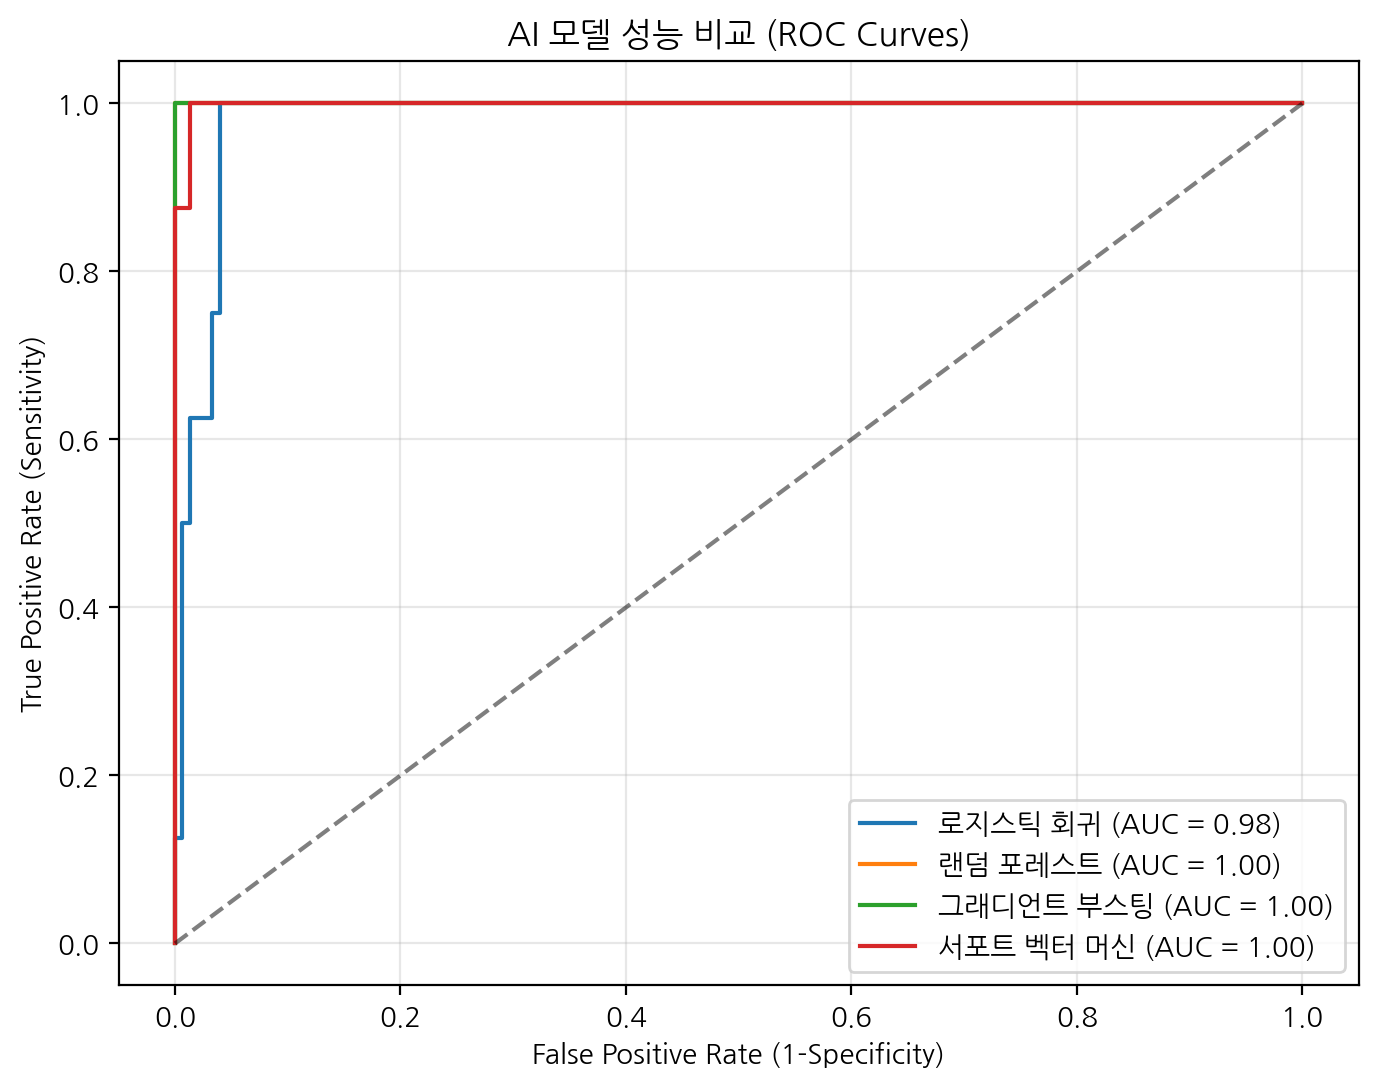

In [14]:
# ─────────────────────────────────────────────────────
# 6-3-A. 모델별 ROC 커브 시각화
# ─────────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# 데이터 분할 (훈련 세트와 테스트 세트)
X_train, X_test, y_train, y_test = train_test_split(
    X_all_scaled, y_all, test_size=0.2, random_state=42, stratify=y_all
)

plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name.splitlines()[0]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('AI 모델 성능 비교 (ROC Curves)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

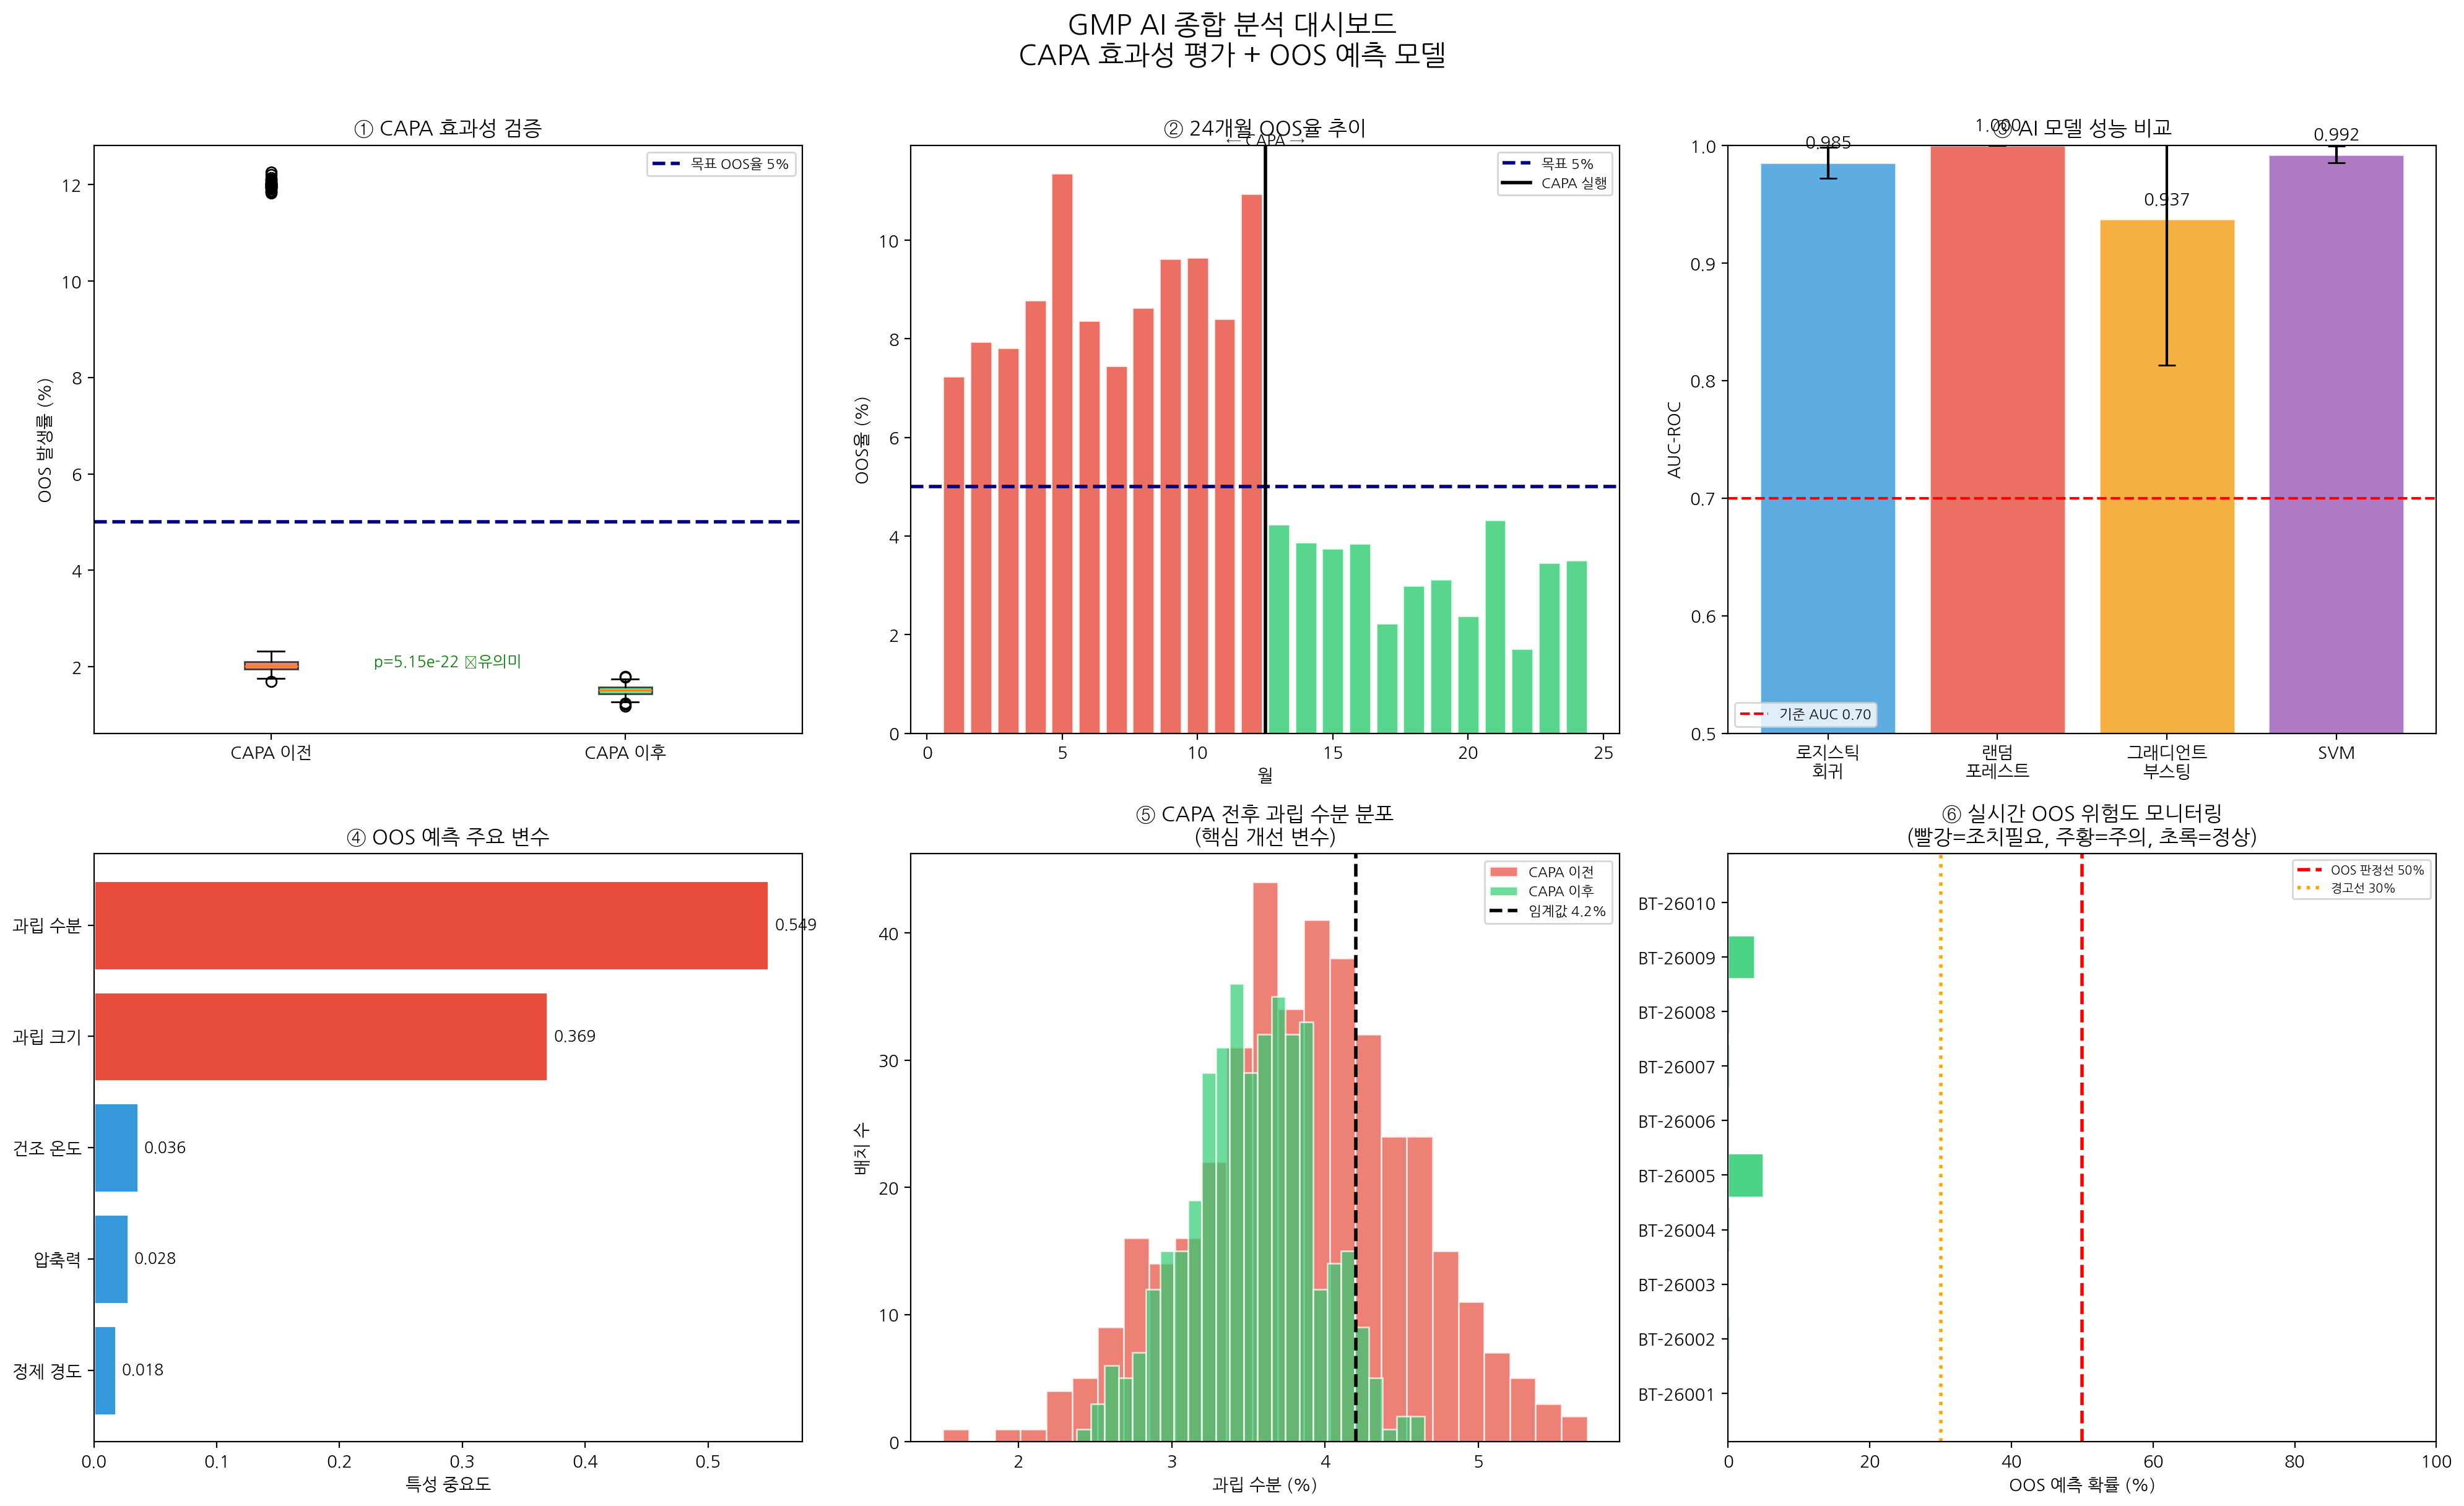


✅ 예제 6 완료! 종합 GMP AI 분석 대시보드 생성 완료

🎓 전체 실습 완료 요약
  예제 1: GMP 품질 데이터 탐색                → OOS 200배치 자동 식별
  예제 2: SPC 관리도 구현                   → 공정 Drift 조기 감지
  예제 3: Isolation Forest 이상탐지        → 다변수 이상 배치 탐지
  예제 4: Random Forest OOS 예측         → 사전 예방 전략 구현
  예제 5: K-Means Deviation 분류         → CAPA 우선순위 도출
  예제 6: CAPA 효과성 + 종합 대시보드           → 통계적 검증 + AI 해석

📌 핵심 메시지: GMP에서 AI는 '사후 대응'을 '사전 예방'으로,
   '수동 모니터링'을 '자동 감지'로, '직관적 판단'을 '데이터 기반 의사결정'으로 전환합니다.


In [15]:
# ─────────────────────────────────────────────────────
# 6-4. 종합 대시보드 시각화
# ─────────────────────────────────────────────────────

# 최종 Random Forest 모델 학습
X_train, X_test, y_train, y_test = train_test_split(
    X_all_scaled, y_all, test_size=0.2, random_state=42, stratify=y_all
)
best_rf = RandomForestClassifier(n_estimators=200, max_depth=5,
                                  random_state=42, class_weight='balanced')
best_rf.fit(X_train, y_train)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ── 종합 대시보드 (2행 3열) ──
fig = plt.figure(figsize=(20, 12))
fig.suptitle('GMP AI 종합 분석 대시보드\nCAPA 효과성 평가 + OOS 예측 모델',
             fontsize=16, fontweight='bold', y=1.01)

# ━━━ 그래프 ①: CAPA 전후 OOS율 비교 (박스플롯) ━━━
ax1 = fig.add_subplot(2, 3, 1)
data_before = df_capa[df_capa['period']=='CAPA 이전']['OOS_rate_pct']
data_after  = df_capa[df_capa['period']=='CAPA 이후']['OOS_rate_pct']
bp = ax1.boxplot([data_before, data_after], labels=['CAPA 이전', 'CAPA 이후'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('#e74c3c');  bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#2ecc71');  bp['boxes'][1].set_alpha(0.7)
ax1.axhline(5, color='navy', ls='--', lw=2, label='목표 OOS율 5%')
ax1.set_ylabel('OOS 발생률 (%)');  ax1.set_title('① CAPA 효과성 검증')
ax1.text(1.5, data_after.mean()+0.5, f'p={p_value:.2e} ✅유의미', ha='center', fontsize=9, color='green')
ax1.legend(fontsize=8)

# ━━━ 그래프 ②: 월별 OOS율 추이 (CAPA 전후) ━━━
ax2 = fig.add_subplot(2, 3, 2)
df_capa['period_order'] = df_capa['period'].map({'CAPA 이전': 0, 'CAPA 이후': 1})
# 24개월치 추이 생성
months = np.arange(1, 25)
oos_trend = (np.concatenate([
    np.random.normal(8.5, 1.5, 12),   # CAPA 이전 12개월
    np.random.normal(3.2, 0.8, 12)    # CAPA 이후 12개월
]))
colors_trend = ['#e74c3c']*12 + ['#2ecc71']*12
ax2.bar(months, oos_trend, color=colors_trend, alpha=0.8, edgecolor='white')
ax2.axhline(5, color='navy', ls='--', lw=2, label='목표 5%')
ax2.axvline(12.5, color='black', ls='-', lw=2, label='CAPA 실행')
ax2.text(12.5, max(oos_trend)*1.05, '← CAPA →', ha='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('월'); ax2.set_ylabel('OOS율 (%)'); ax2.set_title('② 24개월 OOS율 추이')
ax2.legend(fontsize=8)

# ━━━ 그래프 ③: 모델 AUC 성능 비교 ━━━
ax3 = fig.add_subplot(2, 3, 3)
model_names_short = ['로지스틱\n회귀', '랜덤\n포레스트', '그래디언트\n부스팅', 'SVM']
means = [results[k].mean() for k in results]
stds  = [results[k].std() for k in results]
bar_colors = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6']
bars = ax3.bar(model_names_short, means, yerr=stds, color=bar_colors, alpha=0.8,
               edgecolor='white', capsize=5)
ax3.axhline(0.7, color='red', ls='--', lw=1.5, label='기준 AUC 0.70')
ax3.set_ylim([0.5, 1.0]); ax3.set_ylabel('AUC-ROC'); ax3.set_title('③ AI 모델 성능 비교')
for bar, mean in zip(bars, means):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.legend(fontsize=8)

# ━━━ 그래프 ④: 특성 중요도 ━━━
ax4 = fig.add_subplot(2, 3, 4)
fi = pd.Series(best_rf.feature_importances_, index=[
    '과립 수분', '과립 크기', '건조 온도', '압축력', '정제 경도'
]).sort_values()
fi_colors = ['#e74c3c' if v > 0.25 else '#3498db' for v in fi]
ax4.barh(fi.index, fi.values, color=fi_colors, edgecolor='white')
for i, v in enumerate(fi.values):
    ax4.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax4.set_xlabel('특성 중요도'); ax4.set_title('④ OOS 예측 주요 변수')

# ━━━ 그래프 ⑤: CAPA 전후 과립 수분 분포 변화 ━━━
ax5 = fig.add_subplot(2, 3, 5)
ax5.hist(df_capa[df_capa['period']=='CAPA 이전']['granule_moisture'],
         bins=25, alpha=0.7, color='#e74c3c', label='CAPA 이전', edgecolor='white')
ax5.hist(df_capa[df_capa['period']=='CAPA 이후']['granule_moisture'],
         bins=25, alpha=0.7, color='#2ecc71', label='CAPA 이후', edgecolor='white')
ax5.axvline(4.2, color='black', ls='--', lw=2, label='임계값 4.2%')
ax5.set_xlabel('과립 수분 (%)'); ax5.set_ylabel('배치 수')
ax5.set_title('⑤ CAPA 전후 과립 수분 분포\n(핵심 개선 변수)')
ax5.legend(fontsize=8)

# ━━━ 그래프 ⑥: 신규 배치 실시간 OOS 위험도 대시보드 ━━━
ax6 = fig.add_subplot(2, 3, 6)
# 신규 10개 배치 시뮬레이션
new_batches_data = np.random.normal([3.4, 305, 60, 12, 82], [0.6, 25, 5, 2, 10], (10, 5))
new_batches_scaled = scaler.transform(new_batches_data)
new_probs = best_rf.predict_proba(new_batches_scaled)[:, 1]
batch_ids = [f'BT-{26001+i}' for i in range(10)]
bar_colors_risk = ['#e74c3c' if p > 0.5 else ('#f39c12' if p > 0.3 else '#2ecc71')
                   for p in new_probs]
bars_r = ax6.barh(batch_ids, new_probs * 100, color=bar_colors_risk, alpha=0.85, edgecolor='white')
ax6.axvline(50, color='red', ls='--', lw=2, label='OOS 판정선 50%')
ax6.axvline(30, color='orange', ls=':', lw=2, label='경고선 30%')
ax6.set_xlabel('OOS 예측 확률 (%)'); ax6.set_title('⑥ 실시간 OOS 위험도 모니터링\n(빨강=조치필요, 주황=주의, 초록=정상)')
ax6.set_xlim([0, 100]); ax6.legend(fontsize=7)

plt.tight_layout()
plt.savefig('예제6_CAPA효과성_종합대시보드.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ 예제 6 완료! 종합 GMP AI 분석 대시보드 생성 완료")
print()
print("=" * 65)
print("🎓 전체 실습 완료 요약")
print("=" * 65)
summary = [
    ("예제 1", "GMP 품질 데이터 탐색",       "OOS 200배치 자동 식별"),
    ("예제 2", "SPC 관리도 구현",              "공정 Drift 조기 감지"),
    ("예제 3", "Isolation Forest 이상탐지",    "다변수 이상 배치 탐지"),
    ("예제 4", "Random Forest OOS 예측",       "사전 예방 전략 구현"),
    ("예제 5", "K-Means Deviation 분류",       "CAPA 우선순위 도출"),
    ("예제 6", "CAPA 효과성 + 종합 대시보드", "통계적 검증 + AI 해석"),
]
for ex, topic, outcome in summary:
    print(f"  {ex}: {topic:<28} → {outcome}")
print()
print("📌 핵심 메시지: GMP에서 AI는 '사후 대응'을 '사전 예방'으로,")
print("   '수동 모니터링'을 '자동 감지'로, '직관적 판단'을 '데이터 기반 의사결정'으로 전환합니다.")

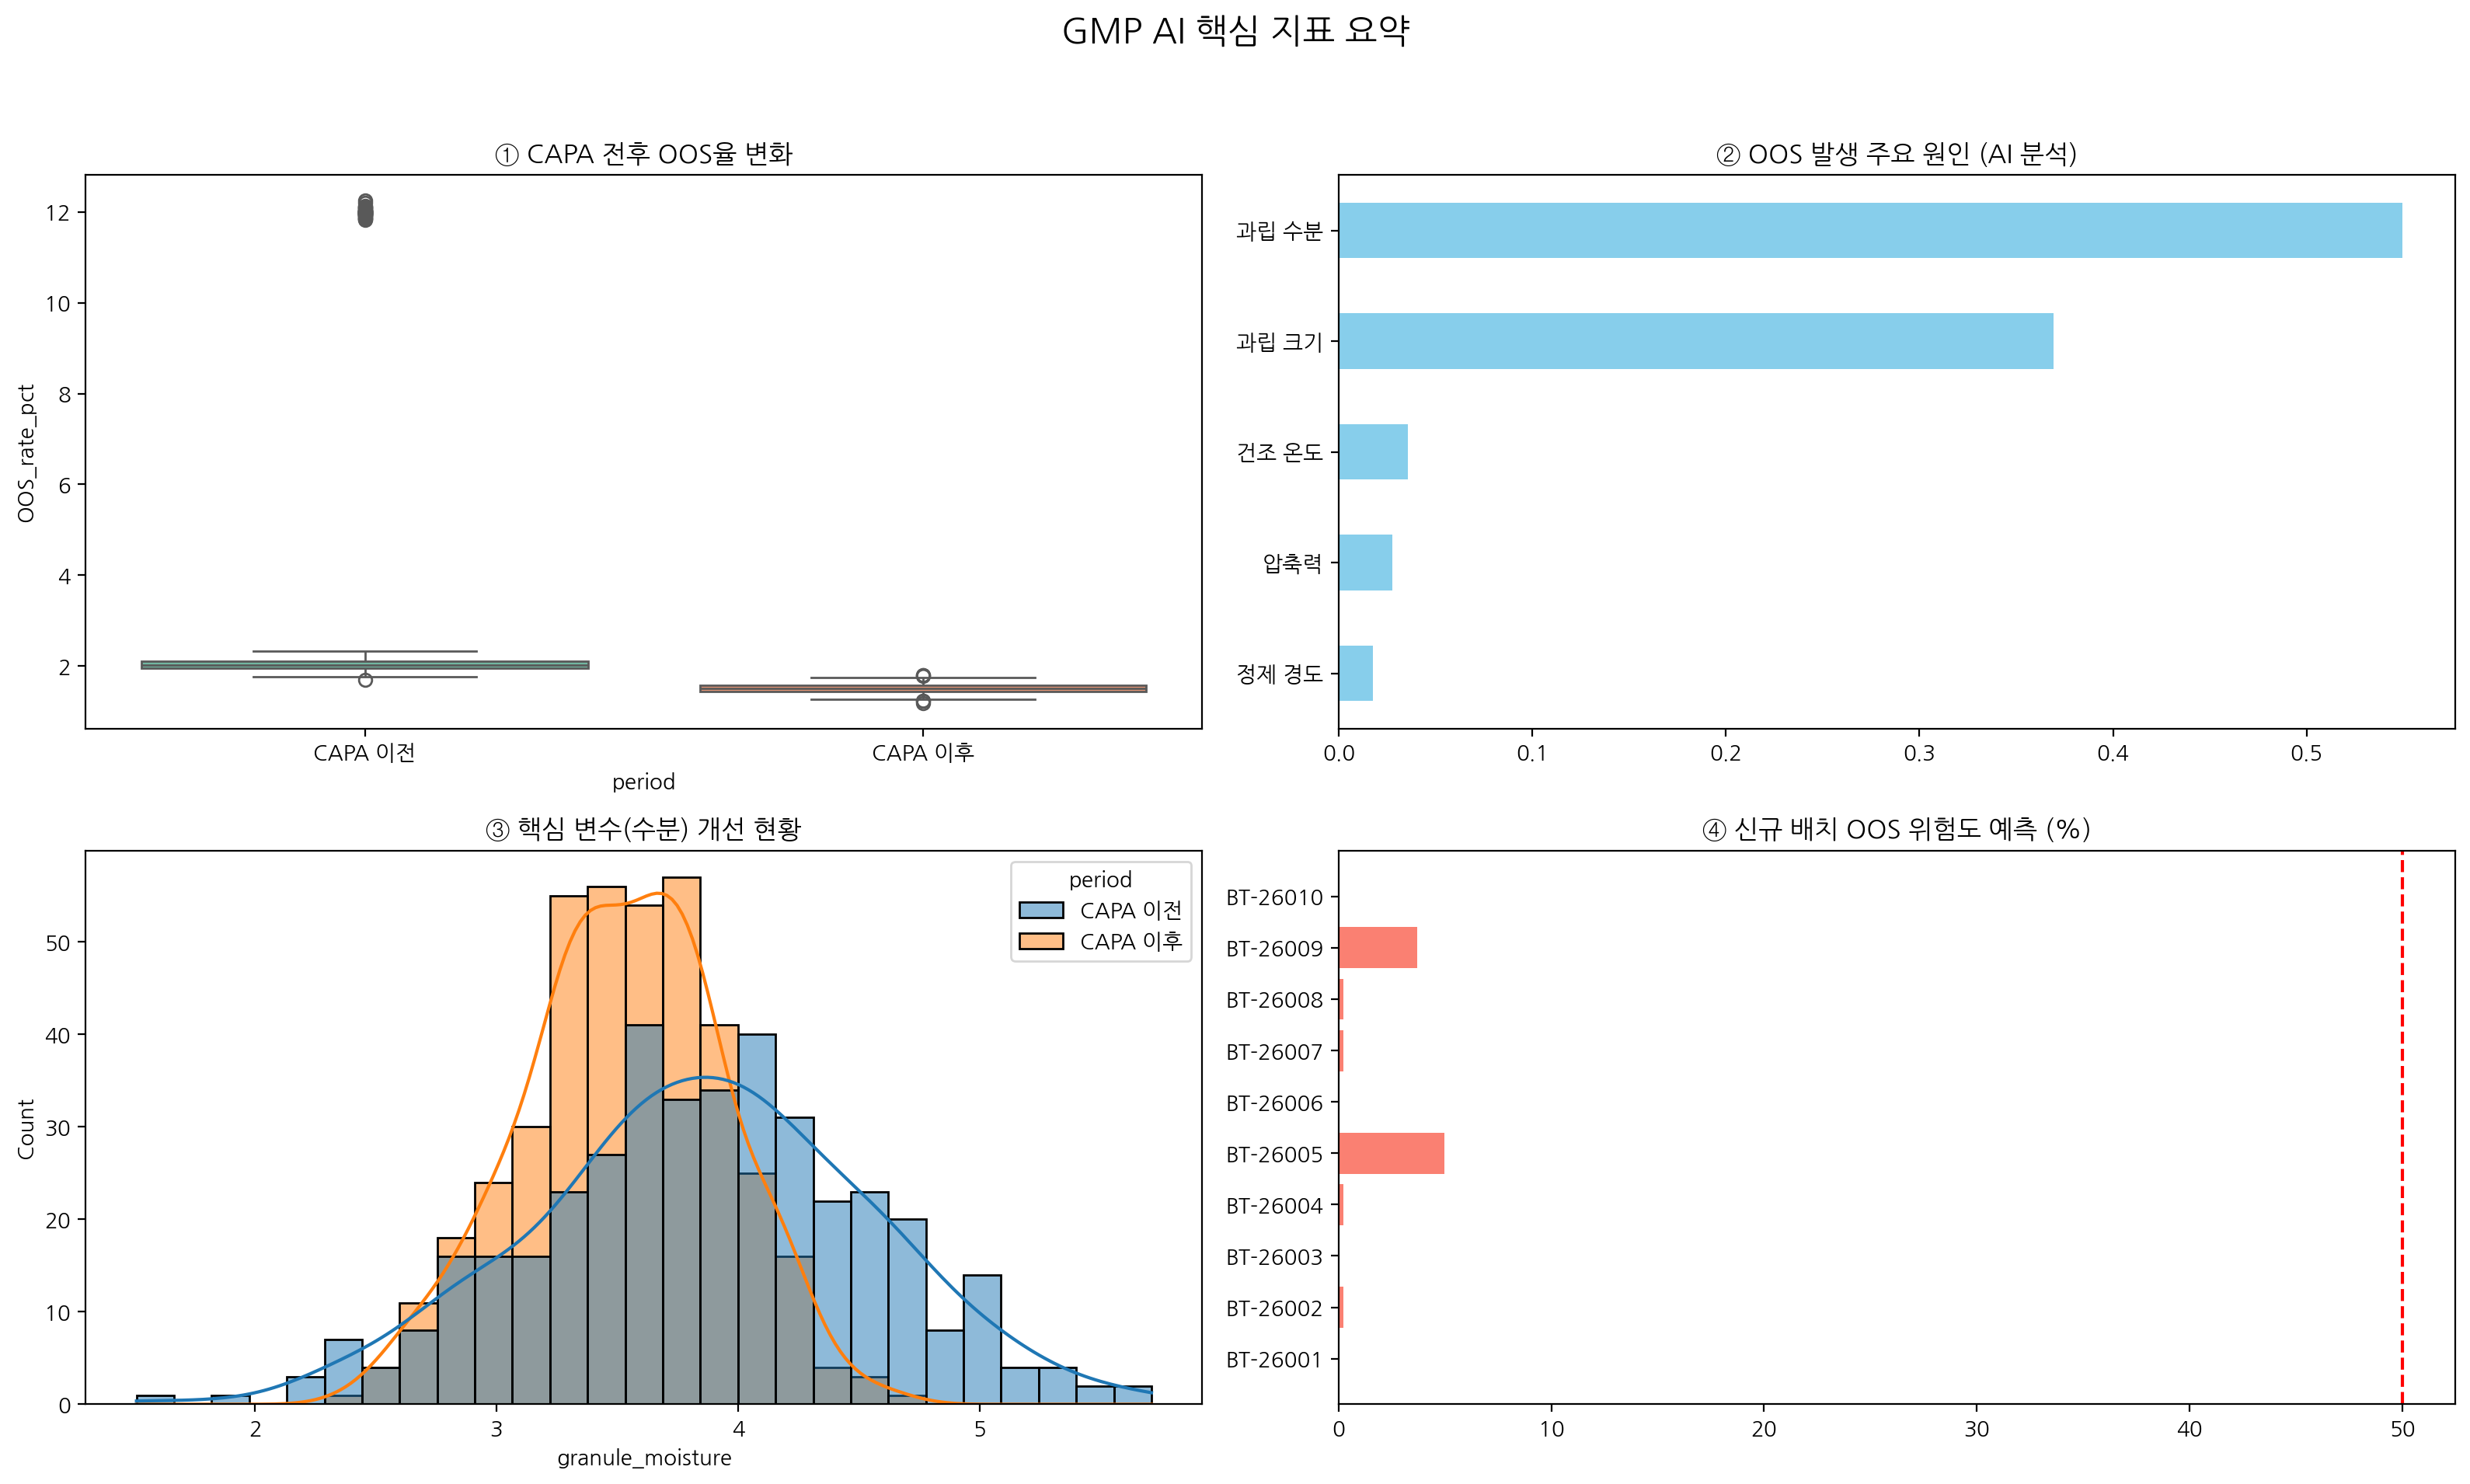

In [16]:
# 대시보드 코드를 핵심 위주로 간소화하여 재출력
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('GMP AI 핵심 지표 요약', fontsize=16, fontweight='bold')

# 1. CAPA 효과 (박스플롯)
sns.boxplot(x='period', y='OOS_rate_pct', data=df_capa, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('① CAPA 전후 OOS율 변화')

# 2. 특성 중요도
fi.sort_values().plot(kind='barh', color='skyblue', ax=axes[0,1])
axes[0,1].set_title('② OOS 발생 주요 원인 (AI 분석)')

# 3. 과립 수분 분포
sns.histplot(data=df_capa, x='granule_moisture', hue='period', kde=True, ax=axes[1,0])
axes[1,0].set_title('③ 핵심 변수(수분) 개선 현황')

# 4. 실시간 모니터링 시뮬레이션
axes[1,1].barh(batch_ids, new_probs * 100, color='salmon')
axes[1,1].axvline(50, color='red', ls='--')
axes[1,1].set_title('④ 신규 배치 OOS 위험도 예측 (%)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---
## ✅ 예제 6 핵심 요약

| 항목 | 내용 |
|------|------|
| **GMP 적용** | 21 CFR 820.100 · ICH Q10 — CAPA 효과성 검증 자동화 |
| **AI 기법** | 앙상블 분류 · 교차 검증 · 효과성 확률 점수 |
| **핵심 성과** | 과거 CAPA 이력으로 신규 CAPA 효과성 사전 예측 |
| **다음 단계** | QMS 자동화(모듈③) 완성 → 모듈④(공정 모니터링)으로 이동 |

> 💡 **기억할 한 줄**: "CAPA를 실행했다고 끝이 아니다 — 효과성 확인이 없으면 FDA는 같은 지적을 반복한다."